# 01 - Meteogram quicklook: NW & NF

Time–height pcolormesh of bulk droplet (NW) and ice-crystal (NF) number
concentrations for every meteogram station in the Zarr store.

Layout: **n_stations rows x 2 columns** (left = NW, right = NF).

### Zarr v2 / v3 compatibility notes

The Zarr stores are written with `zarr_format=2` to work around several
incompatibilities between `xarray` (≥ 2025.4) and `zarr-python` 3.x:

| Issue | Symptom | Resolution |
|-------|---------|------------|
| **Codec API mismatch** | `TypeError: Expected a BytesBytesCodec. Got <class 'numcodecs.blosc.Blosc'>` | Force `zarr_format=2` in `to_zarr()` so `numcodecs.Blosc` is accepted as `compressor`. |
| **Unicode string dtype** | `ValueError: No Zarr data type found that matches {'name': '<U14', 'object_codec_id': 'vlen-utf8'}` | Store string coordinates (e.g. `expname`) as fixed-length bytes (`dtype='S'`) instead of Unicode (`dtype='U'`). zarr-python 3.x infers a `vlen-utf8` codec for `<U` arrays but cannot read it back. |
| **Region writes on coords** | `ValueError: variables … must have at least one dimension in common with the region's dimensions` | Abandoned streaming region-writes; build the full dataset lazily, then write in a single pass. |
| **Fill-value round-trip** | `AttributeError: 'Float32' object has no attribute 'value'` on `open_dataset` | Caused by zarr v3 metadata on read; pinning `zarr_format=2` avoids the issue. |

Existing stores created with `<U` dtypes can be patched locally by converting
the `expname` chunk data from `<U14` → `|S14` and updating `.zarray` /
`.zmetadata` (see `docs/logbook.md`, entry 2026-03-04).

In [1]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from utilities.plotting import get_extpar_data, create_new_jet3, create_fade_cmap, make_pastel

## Configuration

In [3]:
zarr_file = "Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr"
cs_run = "_".join(zarr_file.split("_")[1:5])

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
    extpar_path = root / "COS_in" / "extPar_Eriswil_50x40.nc"
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run
    extpar_path = Path.home() / "data" / "cosmo-specs" / "meteograms" / "extPar_Eriswil_50x40.nc"

# zarr_files = sorted(data_dir.glob(data_dir))
zarr_files = [data_dir / zarr_file]
print(f"Available Zarr stores in {data_dir}:")
for z in zarr_files:
    print(f"  {z.name}")

# pick the store to plot (edit index or path as needed)
zarr_path = zarr_files[-1]
print(f"\nUsing: {zarr_path.name}")
print(f"ExtPar: {extpar_path.name}")

Available Zarr stores in /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254:
  Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr

Using: Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr
ExtPar: extPar_Eriswil_50x40.nc


In [4]:
LBB = slice(30, 50)   # liquid bin range
CBB = slice(30, 50)   # crystal bin range

# experiment index to plot
EXP_IDX = 0

# (output_name, source_var, bin_slice, pos_filter, plot_label, norm_kwargs)
var_config = [
    ("NW_bulk",       "NW",            LBB, True,  "NW – droplet",           dict(vmin=1, vmax=600)),
    ("NF_bulk",       "NF",            CBB, True,  "NF – ice crystal",       dict(norm=mcolors.LogNorm(vmin=1e-3, vmax=10))),
    ("SUM_CONDN",     "SUM_CONDN",     LBB, False, "CONDN – condensation",   dict(norm=mcolors.SymLogNorm(linthresh=1e-4, linscale=0.01))),
    ("SUM_KOLLNI",    "SUM_KOLLNI",    CBB, False, "KOLLNI – collision",     dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
    ("SUM_IMMERN",    "SUM_IMMERN",    CBB, False, "IMMERN – immersion frz", dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
    ("SUM_KOLLNFROD", "SUM_KOLLNFROD", CBB, False, "KOLLNFROD – coll-coal",  dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
]

# only keep variables that actually exist in the zarr store (auto-filter)
# (evaluated after ds is loaded, see next section)

## Load data

In [5]:
ds = xr.open_dataset(zarr_path, engine="zarr")
print("Sizes:", dict(ds.sizes))
print("Data vars:", list(ds.data_vars))

assert "NW" in ds.data_vars and "NF" in ds.data_vars, (
    f"Zarr store must contain NW and NF. Found: {list(ds.data_vars)}"
)

Sizes: {'expname': 5, 'station': 3, 'time': 4033, 'height_level': 20, 'bins': 66, 'height_level2': 21, 'bins_boundaries': 67}
Data vars: ['SUM_CONDNFROD', 'SUM_P_kollqwf', 'SUM_P_BREAN', 'SUM_P_dqfmelt', 'PML', 'SUM_N_deponf', 'SUM_HOMN', 'SUM_kqf', 'NW', 'QV', 'SUM_P_KOLLQFROD', 'SUM_IMMERN', 'SUM_P_dqwmelt', 'SUM_dqfwmelt', 'SUM_N_IMMERN', 'SUM_CONDQWFROD', 'SUM_P_dnfmelt', 'SUM_N_KOLLQFROD_INS', 'SUM_dnwmelt', 'NINP', 'QFS', 'SUM_depoqf', 'SUM_P_deponf', 'SUM_N_kollqwf', 'SUM_N_CONDQFROD', 'QF', 'SUM_CONDQFROD', 'QIA', 'SUM_N_dqfwmelt', 'SUM_N_KOLLNFROD', 'SUM_P_KOLLNFROD_INS', 'SUM_P_KOLLNI', 'SUM_P_CONDQFROD', 'RHO', 'RGRENZ_right', 'SUM_P_KOLLQFROD_INS', 'SUM_dnfmelt', 'SUM_N_KOLLQFROD', 'SUM_CONDN', 'SUM_KOLLNFROD', 'SUM_N_dqffrier', 'PHL', 'SUM_P_dqfwmelt', 'SUM_N_CONDNFROD', 'QWS', 'SUM_P_HOMQ', 'QFA', 'SUM_P_dqffrier', 'SUM_N_KOLLQI', 'SUM_P_kqf', 'SUM_N_HOMN', 'SUM_BREAQ', 'SUM_N_kqwf', 'SUM_N_BREAN', 'SUM_N_KOLLNFRODI', 'SUM_N_CONDN', 'SUM_deponf', 'SUM_kollqwf', 'SUM_P_KOL

In [6]:
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)


In [7]:
ds_exp = ds.isel(expname=EXP_IDX)

# filter var_config to variables present in this zarr store
active_vars = [(out, src, bsl, pos, lbl, nkw) for out, src, bsl, pos, lbl, nkw in var_config
               if src in ds_exp.data_vars]
print(f"Active variables: {[v[0] for v in active_vars]}")

rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None
unit = r"cm$^{-3}$" if rho is not None else r"kg$^{-1}$"

# compute bulk fields for every entry in active_vars
bulk = {}
for out_name, src_name, bin_sl, pos_only, *_ in active_vars:
    data = ds_exp[src_name].isel(bins=bin_sl)
    if pos_only:
        data = xr.where(data > 0, data, np.nan)
    data = data.sum(dim="bins")
    if rho is not None:
        data = data * rho * 1e-6
    bulk[out_name] = data

n_stations = ds_exp.sizes["station"]

# decode bytes→str if expname was stored as fixed-length bytes (zarr v3 compat)
_exp_label = ds.expname.values[EXP_IDX]
exp_label = _exp_label.decode() if isinstance(_exp_label, bytes) else str(_exp_label)

print(f"Experiment: {exp_label}")
print(f"Stations: {n_stations}, variables: {len(active_vars)}")

Active variables: ['NW_bulk', 'NF_bulk', 'SUM_CONDN', 'SUM_KOLLNI', 'SUM_IMMERN', 'SUM_KOLLNFROD']
Experiment: 20260304110446
Stations: 3, variables: 6


In [8]:
lat2D, lon2D, hsurf = get_extpar_data(str(extpar_path))
print(f"ExtPar grid: {lat2D.shape}, height range: {hsurf.min():.0f}–{hsurf.max():.0f} m")

ExtPar grid: (26, 36), height range: 597–1205 m


## Quicklook: time–height cross-sections

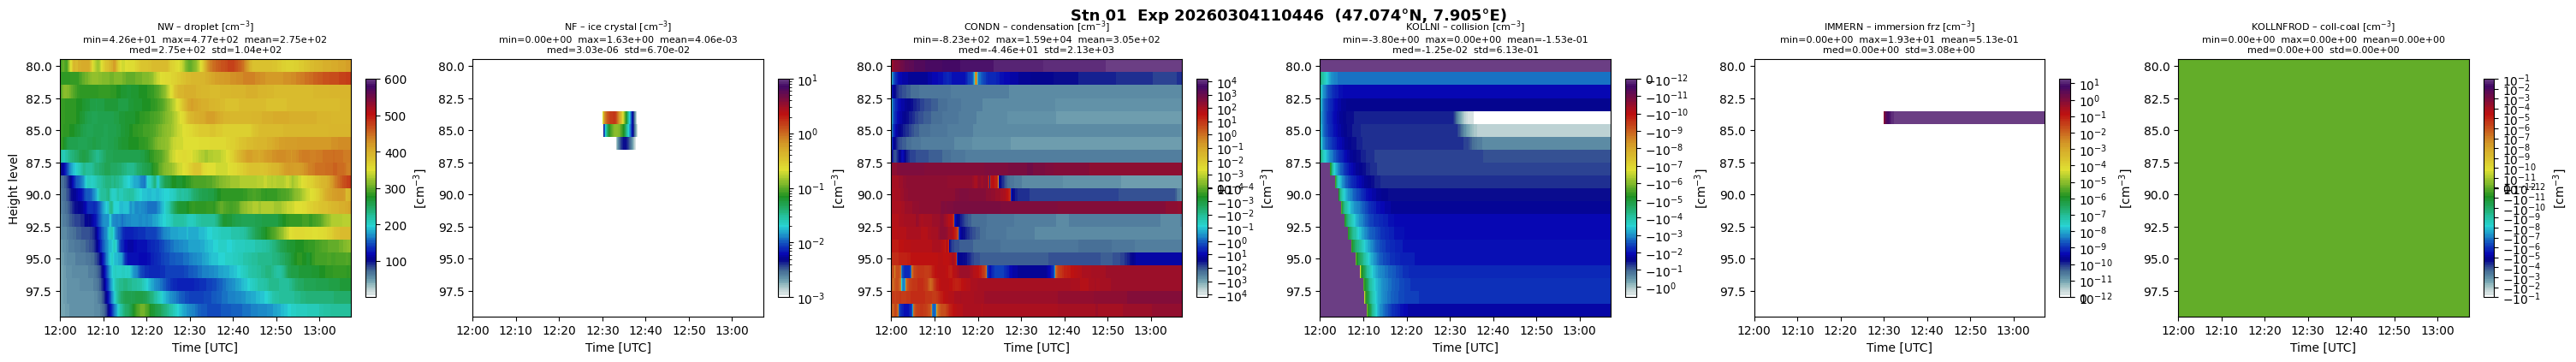

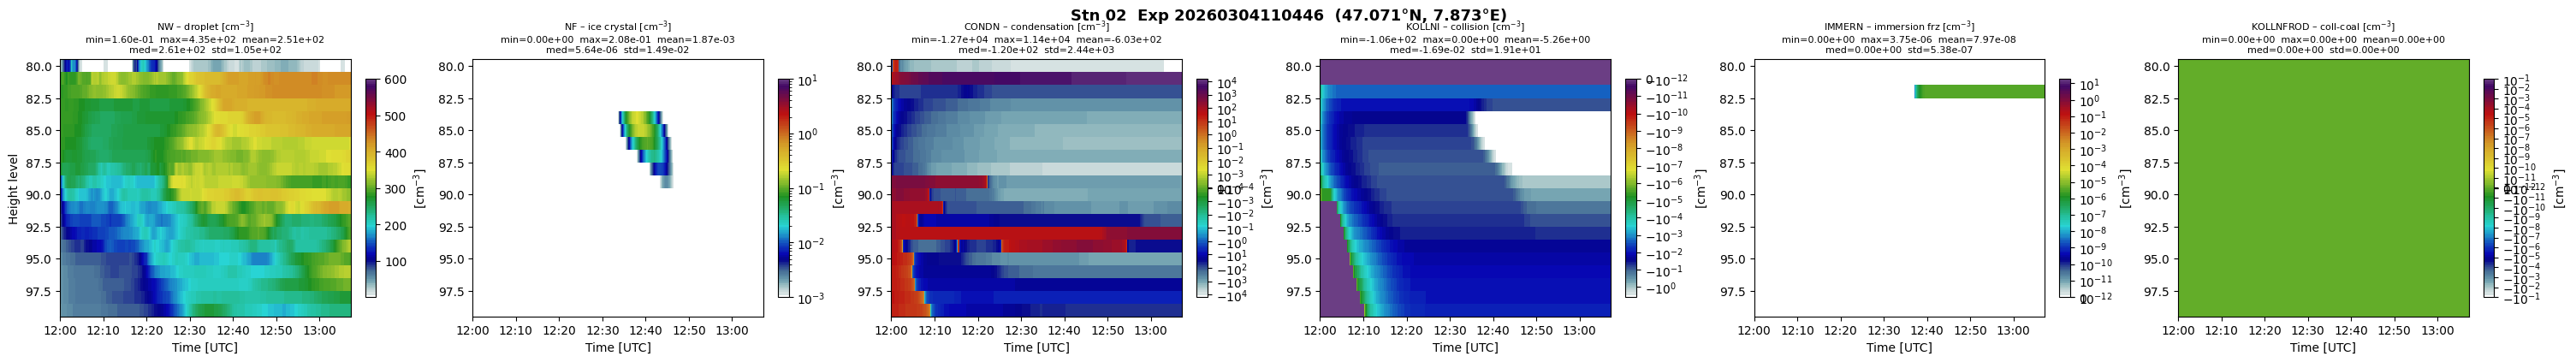

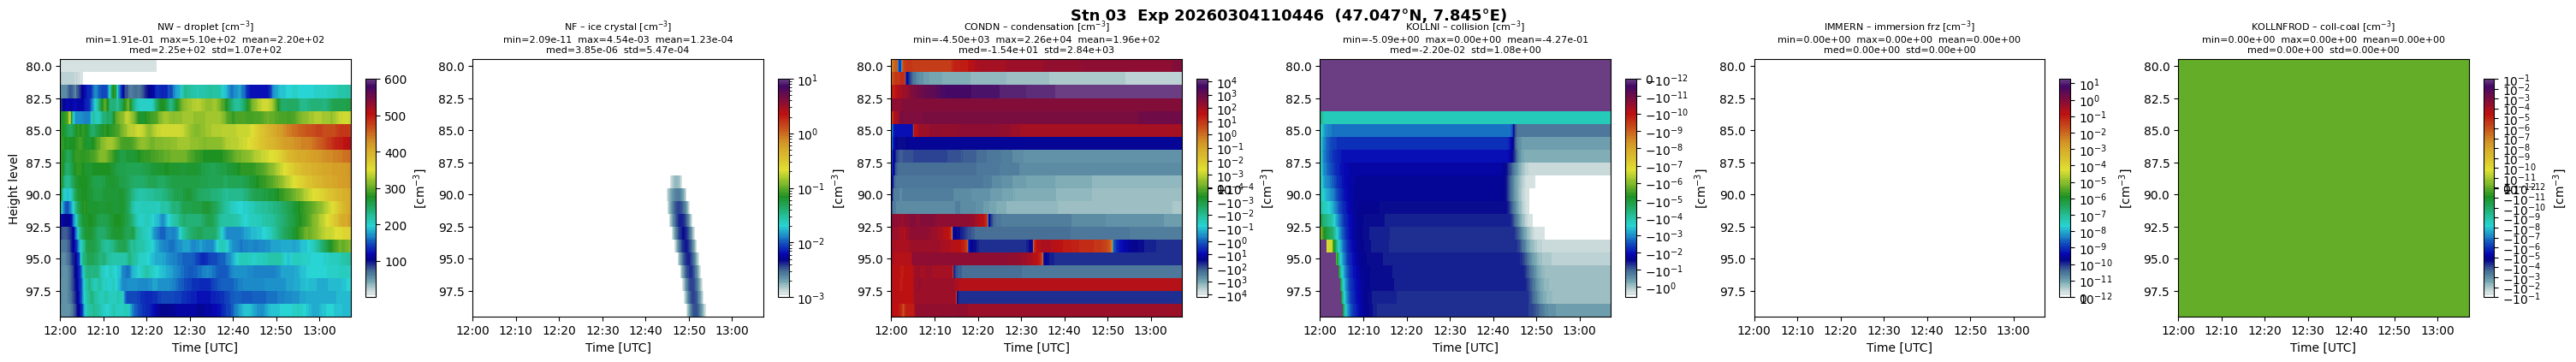

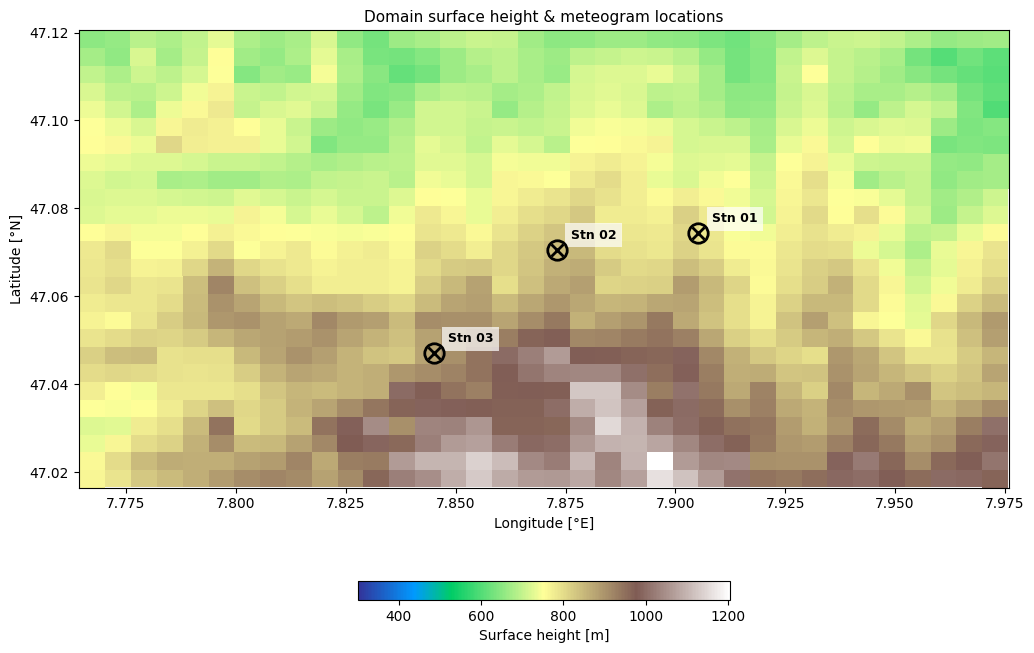

In [9]:
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)

n_vars = len(active_vars)
plot_kw = dict(x="time", y="height_level", cmap=new_jet3_soft,
               add_colorbar=False, add_labels=False)

# one figure per station (mirrors the per-file loop of nb02)
for i in range(n_stations):
    slat = float(ds_exp.station_lat.values[i])
    slon = float(ds_exp.station_lon.values[i])
    sid  = int(ds_exp.station.values[i])
    title = f"Stn {sid:02d}  Exp {exp_label}  ({slat:.3f}°N, {slon:.3f}°E)"

    fig, axes = plt.subplots(1, n_vars, figsize=(n_vars * 5, 4), constrained_layout=True)
    if n_vars == 1:
        axes = [axes]

    for idx, (vname, _, _, _, vlabel, norm_kw) in enumerate(active_vars):
        ax = axes[idx]
        pcm = bulk[vname].isel(station=i).plot.pcolormesh(ax=ax, **norm_kw, **plot_kw)

        d = bulk[vname].isel(station=i).values.ravel()
        d = d[np.isfinite(d)]
        if d.size:
            stats = (f"min={d.min():.2e}  max={d.max():.2e}  mean={d.mean():.2e}\n"
                     f"med={np.median(d):.2e}  std={d.std():.2e}")
        else:
            stats = "no finite data"
        ax.set_title(f"{vlabel} [{unit}]\n{stats}", fontsize=8)

        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.set_xlabel("Time [UTC]")
        if idx == 0:
            ax.set_ylabel("Height level")

        fig.colorbar(pcm, ax=ax, label=f"[{unit}]", shrink=0.85)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.show()

# ── Surface height map with station locations ──
fig, ax_map = plt.subplots(figsize=(12, 9))
pm = ax_map.pcolormesh(lon2D, lat2D, hsurf, cmap="terrain", vmin=300, shading="auto")
fig.colorbar(pm, ax=ax_map, label="Surface height [m]",
             orientation="horizontal", shrink=0.4, pad=0.08)

for i in range(n_stations):
    slat = float(ds_exp.station_lat.values[i])
    slon = float(ds_exp.station_lon.values[i])
    sid  = int(ds_exp.station.values[i])
    ax_map.plot(slon, slat, "o", ms=14, mfc="none", mec="k", mew=2, zorder=5)
    ax_map.plot(slon, slat, "x", ms=9, mew=2, color="k", zorder=6)
    ax_map.annotate(f"Stn {sid:02d}", (slon, slat), textcoords="offset points",
                    xytext=(10, 8), fontsize=9, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

ax_map.set_xlabel("Longitude [°E]")
ax_map.set_ylabel("Latitude [°N]")
ax_map.set_title("Domain surface height & meteogram locations", fontsize=11)
ax_map.set_aspect("equal")
ax_map.set_anchor("C")
plt.show()